In [22]:
import matplotlib.pyplot as plt
import torch
from cryosim.icemaker import Icemaker
from cryosim.fft_tools import fft3
from cryosim.plotting_tools import plot3d
import mrcfile

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Frame 100 of MD-simulation (can't upload all frames due to memory)

In [2]:
mdsim_frame100 = torch.load("../ice-data/mdsim_frame100_ice_deltas.pt")

In [3]:
mdsim_frame100.shape

torch.Size([200, 200, 200])

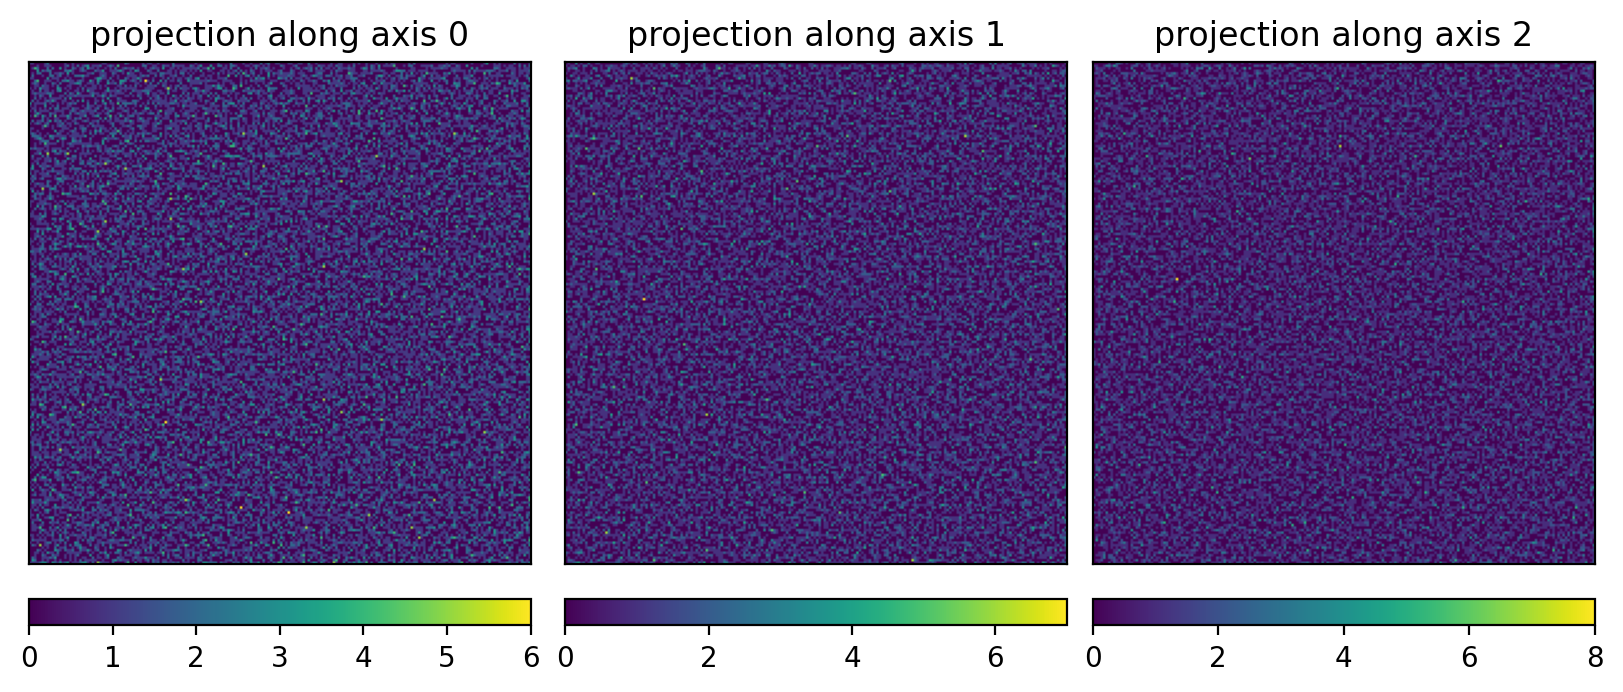

In [4]:
plot3d(mdsim_frame100)

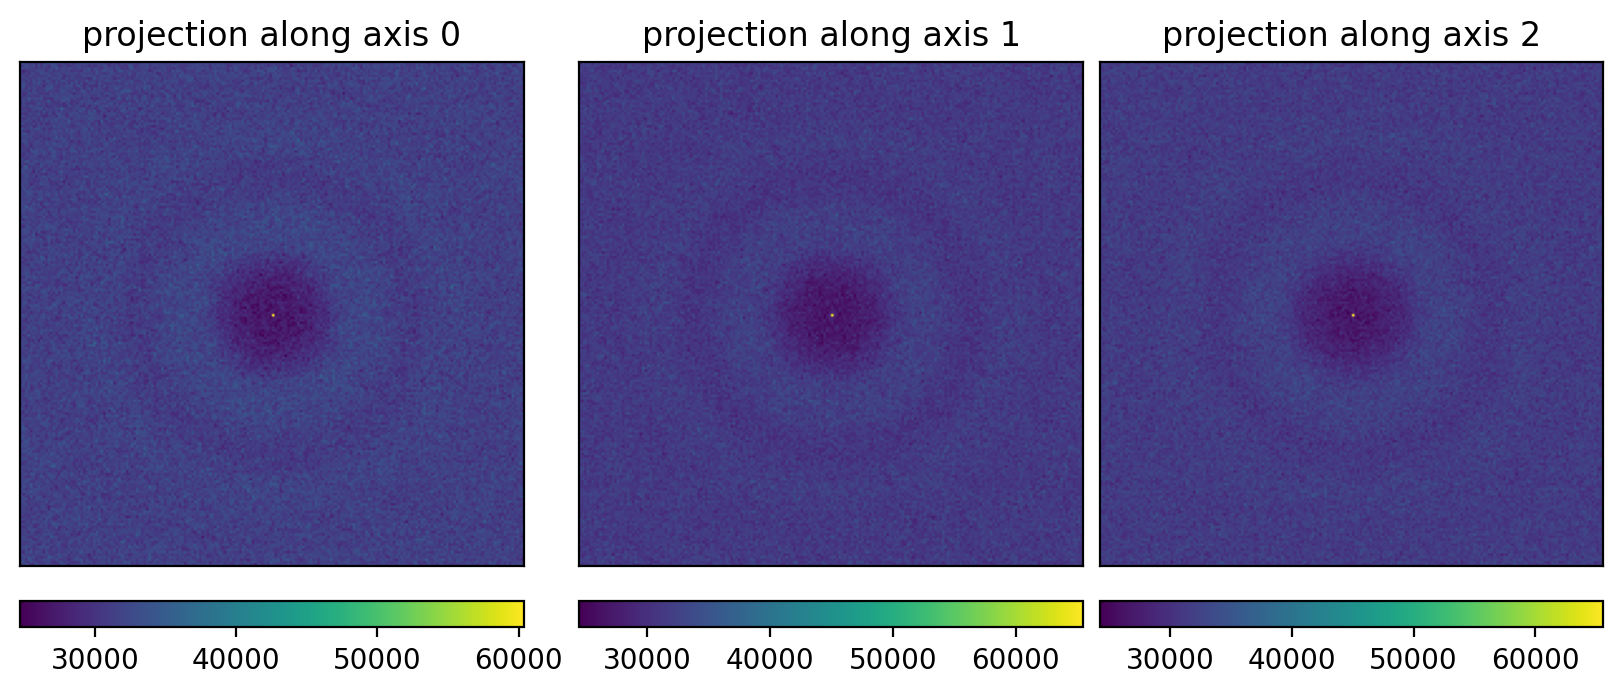

In [5]:
plot3d(torch.abs(fft3(mdsim_frame100)))

In [6]:
# Safer implementation
fft_vals = torch.fft.fftn(mdsim_frame100.float())
magnitude = torch.abs(fft_vals)

# Create random phase
phase = torch.rand_like(mdsim_frame100) * 2 * torch.pi

# Option: Ensure the DC component (0,0,0) has 0 phase
# so the sum remains a purely real positive number
phase[0, 0, 0] = 0

new_fft = magnitude * torch.exp(1j * phase)
newice = torch.fft.ifftn(new_fft).real

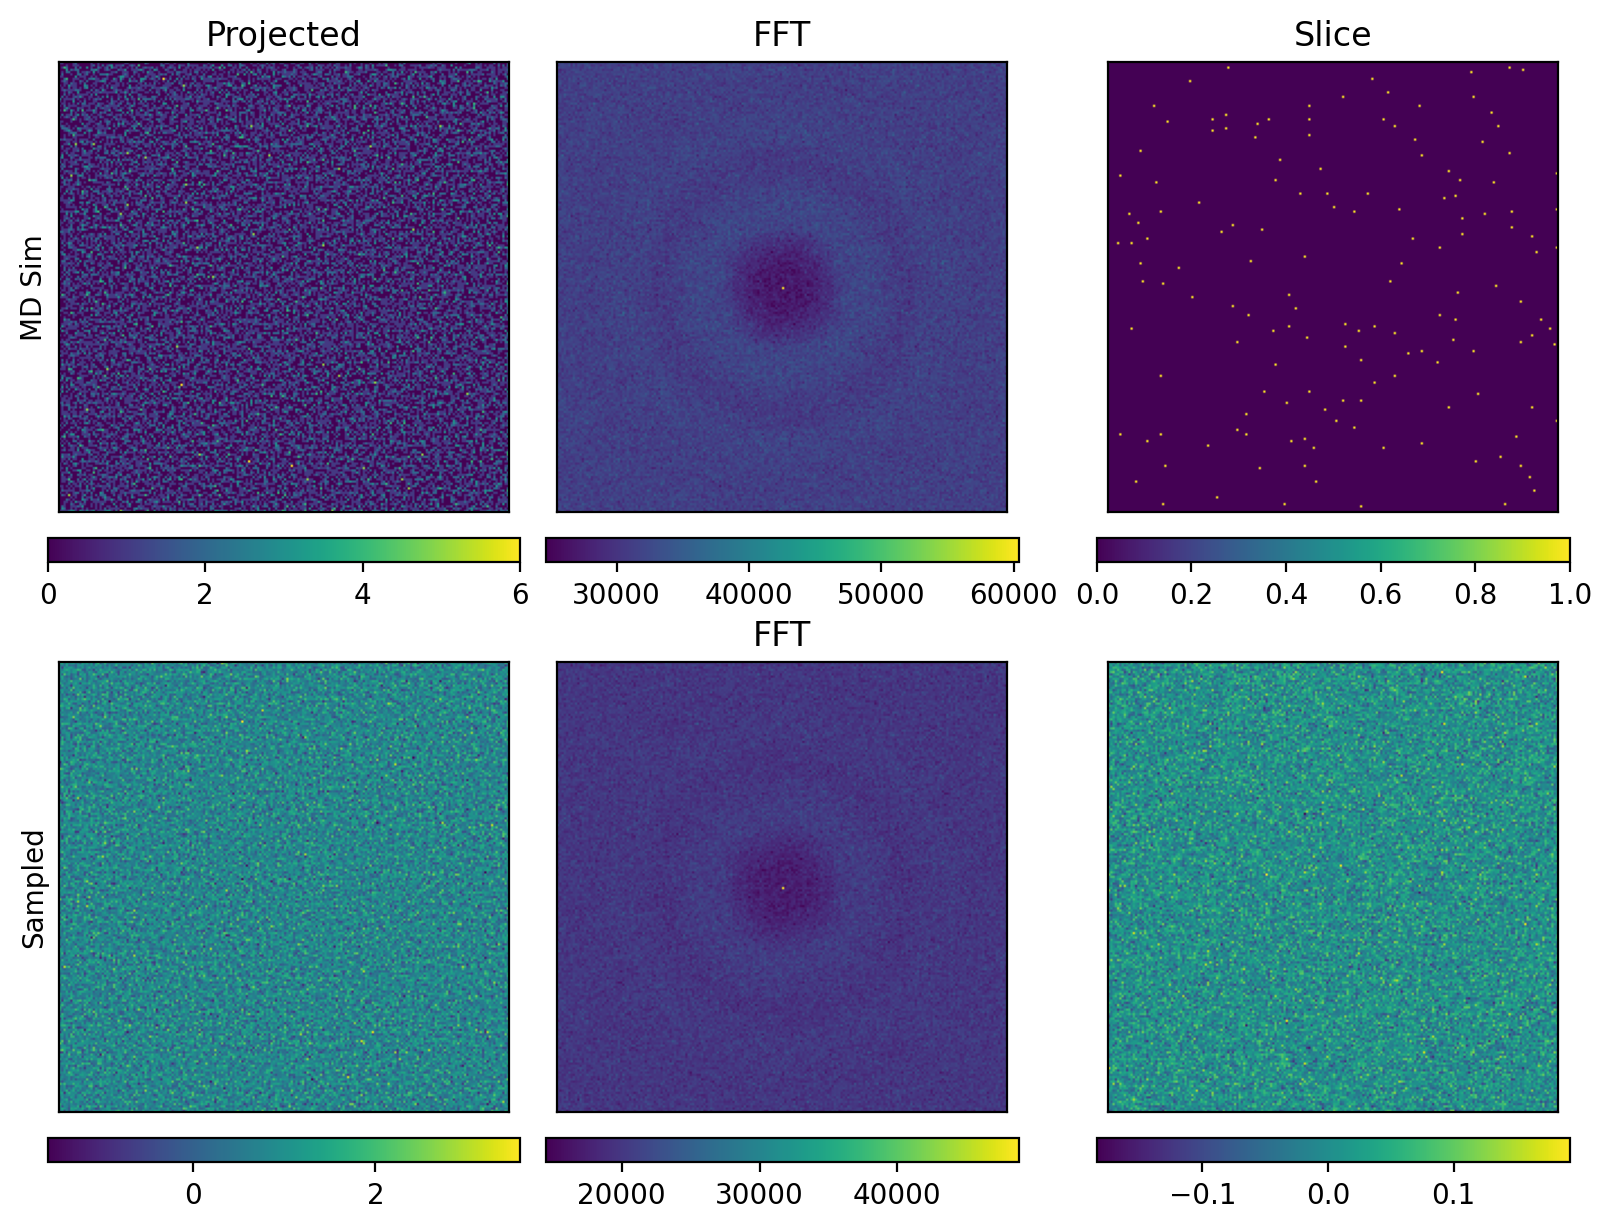

In [7]:
fig, axes = plt.subplots(2, 3, dpi=200, constrained_layout=True, figsize=(8, 6))
[ax.set(yticks=[], xticks=[]) for ax in axes.ravel()]
ax = axes[0, 0]
im = ax.imshow(mdsim_frame100.sum(0))
ax.set_title("Projected")
ax.set_ylabel("MD Sim")
fig.colorbar(im, ax=ax, location="bottom")

ax = axes[0, 1]
im = ax.imshow(torch.abs(fft3(mdsim_frame100)).sum(0))
ax.set_title("FFT")
fig.colorbar(im, ax=ax, location="bottom")

ax = axes[0, 2]
im = ax.imshow(mdsim_frame100[100])
ax.set_title("Slice")
fig.colorbar(im, ax=ax, location="bottom")

ax = axes[1, 0]
im = ax.imshow(newice.sum(0))
ax.set_ylabel("Sampled")
fig.colorbar(im, ax=ax, location="bottom")

ax = axes[1, 1]
im = ax.imshow(torch.abs(fft3(newice)).sum(0))
ax.set_title("FFT")
fig.colorbar(im, ax=ax, location="bottom")

ax = axes[1, 2]
im = ax.imshow(newice[100])
fig.colorbar(im, ax=ax, location="bottom")

plt.show()

## Big ice assembly

In [13]:
im = Icemaker(n=256, dx=2.0, correction_factor=1.5)

In [19]:
bigice = im.generate_big_ice((1, 512, 2048, 2048))

Output()

Output()

In [25]:
with mrcfile.open(
    "/mnt/cbis/home/e0788253/polnet/gui/tomo_density_2048x2048x512_2A.mrc"
) as mrc:
    tomo = torch.as_tensor(mrc.data[...].copy())

In [26]:
tomo.shape

torch.Size([512, 2048, 2048])

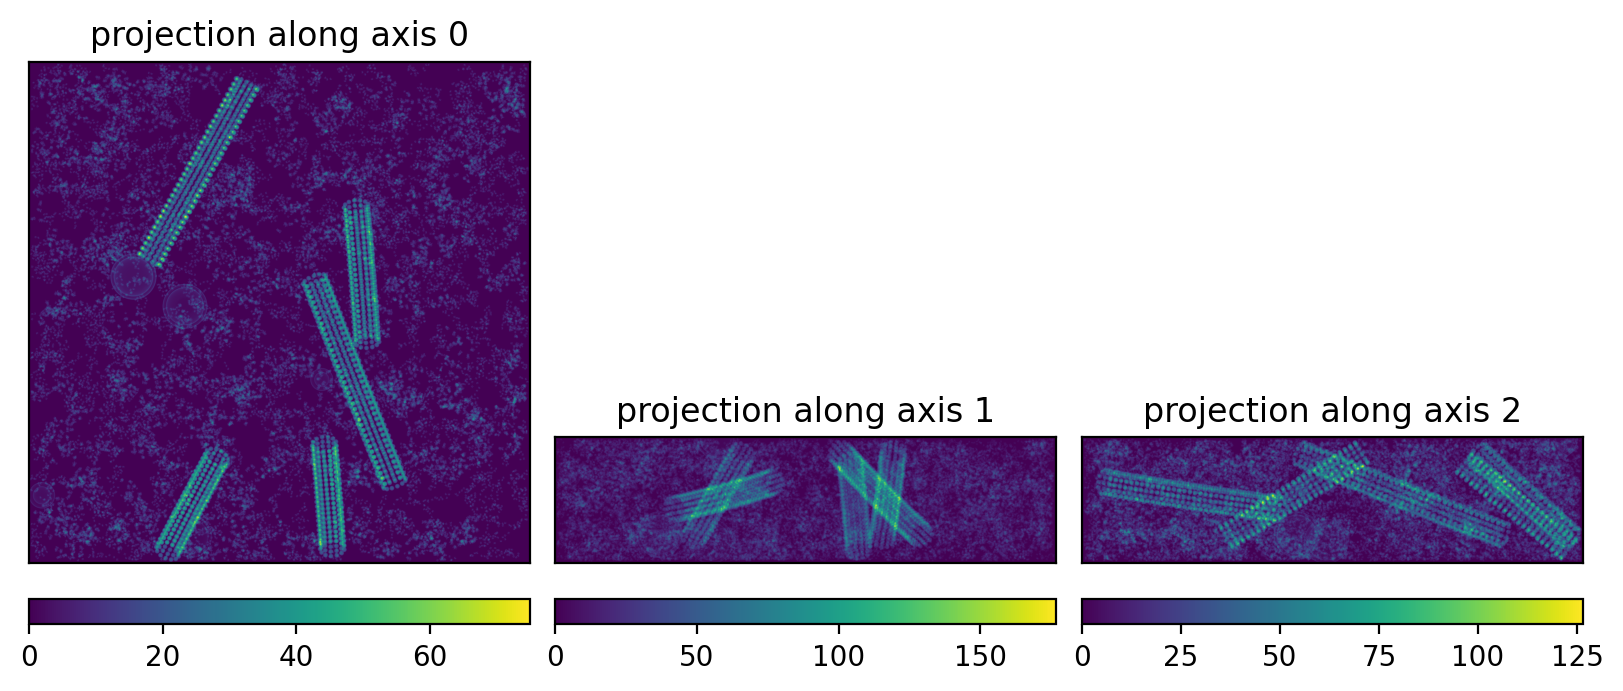

In [27]:
plot3d(tomo)